# Oligo Pool Order
- input: design output .xlsx file from IDT, post target_filter.sh fragment fasta file
- output: selected probe oligo pool order, target info.txt file (each line is a target with probe list)
- Note: I am writing this to replace/modify previous Chris script Custom-Array_Order.v2.py, because there has been change in IDT output format, also Chri's filter/selection logic does not make sense to me, for example:
 - prioritize smaller frags becasue bisulfite converstion preserve small frags --> but this target enrichment is not related to previous BS step
 - prioritize high repeat number --> I found lower repeat number more informative
 - filtering out AACGTT for AclI enzyme cut site (this was based on expriment testing if this enzyme can digest adapter dimer, not used anymore)
    
    

In [1]:
import pandas as pd
import glob
from Bio import SeqIO
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pickle
import random
import seaborn as sns

# Path

In [2]:
# IDT excel output file (can read multiple)
paths = glob.glob("IDToutput_1ntMS_10-50bp_mm39/DesignOutput_05845849_Cheng_Msel_all/DesignProbes-XGEN.CE09110C00674AADAEE74C7DB1CE35E4.xlsx")
paths

['IDToutput_1ntMS_10-50bp_mm39/DesignOutput_05845849_Cheng_Msel_all/DesignProbes-XGEN.CE09110C00674AADAEE74C7DB1CE35E4.xlsx']

In [3]:
# this is the fasta file post filter by target_filter.sh
fasta_file = 'mm39_10-50bp_fragSeq.MseI.filtered.fasta'

# Read IDT probe design excel file

In [4]:
# read first column as index, convert all to string type
res_ls = [pd.read_excel(p, index_col=0, dtype=str) for p in paths]

/usr/conda/envs/retrace/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [5]:
res = pd.concat(res_ls)
res 

,Start,Stop,Name,Score,Strand,Code,Seq,len,GC
Chromosome,,,,,,,,,
chr10_128873771_128873782_11xA,0,120,Target=1972;ProbeIdx=1;chr10_128873771_1288737...,500,+,remove,TAAATAGACAAGACCAGACCAGAATCTTTCCAGAGCATATGGGAAT...,120,45.83
chr16_35605706_35605729_23xA,0,120,Target=39553;ProbeIdx=1;chr16_35605706_3560572...,500,+,remove,TAAAAATGAGCCTTACAGGAGGATCTCTGTGACCTCAGTCCAGGAC...,120,34.17
chr19_15459463_15459475_12xA,0,120,Target=53338;ProbeIdx=1;chr19_15459463_1545947...,500,+,remove,TAAAAGAAATGTACACAATGAGTTCCAGGGCAGCCAGAGATACATA...,120,31.67
chr5_40801392_40801408_16xT,0,120,Target=97103;ProbeIdx=1;chr5_40801392_40801408...,500,+,remove,TAATCTTTGACAAAGGAGCTAAAAACCATCCAGTAGAGAAAAAGGA...,120,27.5
chr5_83067384_83067410_26xA,0,120,Target=99630;ProbeIdx=1;chr5_83067384_83067410...,500,+,remove,TAACAAAGTTGTAATTTCAGCACTGATACAGAAAAAAAAATAATAA...,120,30.83
...,...,...,...,...,...,...,...,...,...
chrX_GL456233v2_random_422406_422416_10xT,100,220,Target=136317;ProbeIdx=11;chrX_GL456233v2_rand...,0,+,good,TTTTCTAGAATTAGAACTCACTATGCAGCCTAGCCTTGAAAAATCC...,120,33.33
chrX_GL456233v2_random_460324_460334_10xT,30,150,Target=136320;ProbeIdx=4;chrX_GL456233v2_rando...,0,+,good,CTGTGACAAGAGAAACGTCTTTTCCTTGAATATACCCTGTTGATTT...,120,34.17
chrX_GL456233v2_random_466880_466892_12xA,0,120,Target=136321;ProbeIdx=1;chrX_GL456233v2_rando...,0,+,good,TAATGTAATATGTTCAAATCCTCCCCTGATGTTATCACTACACTAT...,120,29.17


In [6]:
set(res.Code)

{'good', 'remove', 'risk'}

## Quick Stats & filter pass probe 
- IDT recommend removing probe labeled with remove and risk (include only good), also mTDNA/rDNA hit.

In [7]:
# total pre-filter probe
res.shape[0]

281660

In [8]:
# sometimes IDT include mtDNA/rDNA hit column
#sum(res['mtDNA/rDNA hit'] == 'no')

In [9]:
res['Code'].value_counts()

Code
good      190320
remove     75043
risk       16297
Name: count, dtype: int64

In [10]:
# filter probe and calculate pass rate
res_pass = res[res.Code == 'good']
#res_pass = res.query('Code == "good" and `mtDNA/rDNA hit` == "no"')  # newest IDT output includes mtDNA/rDNA hit

print(f"Num of Pass Probe: {res_pass.shape[0]}/{res.shape[0]} ({round(res_pass.shape[0]/res.shape[0]*100,2)})%")

Num of Pass Probe: 190320/281660 (67.57)%


In [11]:
n_uniq_target = len(res_pass.index.unique())
n_uniq_target

105557

In [12]:
tile_ratio = res_pass.shape[0]/n_uniq_target
tile_ratio

1.8030069062212832

In [13]:
res_pass.head()

,Start,Stop,Name,Score,Strand,Code,Seq,len,GC
Chromosome,,,,,,,,,
chr3_33580017_33580040_23xT,10,130,Target=80628;ProbeIdx=2;chr3_33580017_33580040...,50,+,good,TCAACTCTAACAGTTTATTTTCTTTTTTCTTTCTTTTCTTTTTTTT...,120,26.67
chrX_164497249_164497266_17xA,0,120,Target=131940;ProbeIdx=1;chrX_164497249_164497...,49,+,good,TAAGATCTTATGTAGAAAAAAACAAAAACAAAACAGATACAAATAC...,120,25
chr19_35682622_35682660_38xA,70,190,Target=54609;ProbeIdx=8;chr19_35682622_3568266...,46,+,good,AAGGATTGCAGAGTATCGCCTTACCTCTGAGGAACCTGATGTATAA...,120,25.83
chr16_67611717_67611733_16xA,40,160,Target=41623;ProbeIdx=5;chr16_67611717_6761173...,30,+,good,AATTCTGACACAGTGAAGGATGTTGCTTCTCCAAAGAGTGAAGGGC...,120,29.17
chr10_30866906_30866916_10xT,0,120,Target=3021;ProbeIdx=1;chr10_30866906_30866916...,27,+,good,TAATTGGTGCTGGCCAGATACTTCTGGGTGTGAAACCATCCACAGG...,120,35.83


# Read fragment fasta file
- read and filter MS with flanking region >=5bp

In [14]:
# This is from Chris old script, comment out filter AACCGTT site (does not make sense, probably old design) but keep flanking MS >=5bp filter
def importFasta(fasta_file):
    badTargets = []
    fastaDict = {}
    for fasta in SeqIO.parse(fasta_file, "fasta"):
        frag_seq = str(fasta.seq).upper()
        fastaDict[fasta.id] = frag_seq
        #if "AACGTT" in frag_seq:
        #    badTargets.append(fasta.id)
        #    continue
        #Determine whether there is sufficient unique flanking sequences around MS (>=5bp)
        sub_info = str(fasta.id).split('_')[-1]
        (num_sub, sub_seq) = sub_info.split('x')
        MS_seq = sub_seq*int(num_sub)
        MS_start = frag_seq.find(MS_seq)
        MS_end = MS_start + len(MS_seq)
        if MS_start < 5 or MS_end > len(frag_seq)-5:
            badTargets.append(fasta.id)
    print("Number of bad targets:\t" + str(len(badTargets)))
    return badTargets, fastaDict

In [15]:
badTargets, fastaDict = importFasta(fasta_file)

Number of bad targets:	14157


In [16]:
len(fastaDict)

139107

# Generate probe dictionary 
- Since the IDT output format has changed, it would be easier to change the first column target info to match current IDT output. 
- This format will be differnt than Chris's but I dont expect he will use these info (excpet for the first target name) for downstram analysis, so should be fine, we will see once I run the whole pipeline

In [17]:
def importProbes(res_pass, badTargets, fastaDict):
    '''
    Input: 
        res_pass: dataframe with probe pass filter from previous step reading IDT excel output
        badTargets: defined bad targets from importFasta() 
        fastaDict: fragment ID and seq in dictionary format from importFasta()
    Output:
        probeDict: combine all previous probe info into a dictionary (actually more like a target dictionary)
    '''
    
    probeDict = {}
    
    # loop through all rows(probes), add tqdm to see progess bar
    for i in tqdm(range(res_pass.shape[0]), position=0, leave=True):
        
        targetID = res_pass.index[i]
        if targetID not in badTargets:
        
            # get probe seq and add adapter seq for probe production
            probe = "TGTAAGGCACATCTCGGATC" + res_pass.iloc[i,6] + "ATCCGACGAGAATCTTGCTTCCCTATAGTGAGTCGTATTA"  

            # new target
            if targetID not in probeDict.keys():
                # just inclue targetID for now as target info, does not make sense to include other probes info
                info = targetID
                # get subunit info from targetID
                sub_info = targetID.split('_')[-1]
                (num_sub, sub_seq) = sub_info.split('x')
                # get frag seq from fasta file
                frag_seq = fastaDict[targetID]
                
                # save information to probeDict
                probeDict[targetID] = {} 
                probeDict[targetID]['info'] = info
                probeDict[targetID]["frag_seq"] = frag_seq
                probeDict[targetID]["fragLen"] = len(frag_seq)
                probeDict[targetID]["num_sub"] = int(num_sub)
                probeDict[targetID]["sub_seq"] = sub_seq
                probeDict[targetID]["sub_len"] = len(sub_seq)
                probeDict[targetID]["probe_list"] = [probe]
            
            # target already exist, just append additional probe to list
            else:
                probeDict[targetID]["probe_list"].append(probe)
    
    return(probeDict)
    

In [18]:
probeDict = importProbes(res_pass, badTargets, fastaDict)

  0%|          | 0/190320 [00:00<?, ?it/s]

100%|██████████| 190320/190320 [00:38<00:00, 4903.62it/s]


In [19]:
# save dictionary
#with open('probeDict.pkl', 'wb') as dict_out:
#    pickle.dump(probeDict, dict_out)
    
# # load dictionary
with open('probeDict.pkl', 'rb') as dict_input:
    probeDict = pickle.load(dict_input)

In [20]:
# n_targets
len(probeDict.keys())

94335

# Probe selection & Output info.txt
- Oligo order length is 180nt (120bp probe + 60bp adapter)
- Twist price tier (150-200nt) 18k-24k pool is ~USD$6000
- Test 12k probe set first since there's a lot of new varaibles to make sure (eg. 120bp probe length, new script)

In [21]:
def selectProbes(probeDict, output_file, info_file, numProbes, seed=1):
    '''
    output_file: this probe text file is for oligo pool order
    info_file: this contains probe target info for future data analysis
    seed: set this to get same random result 
    '''
    TW_probes = {}
    num_counter = 0
    TW_output = open(output_file, 'w') # Twist oligo pool order
    info_output = open(info_file, 'w')
    target_list = list(probeDict.keys())
    # random select targetID first to test, not sorted
    random.seed(seed)
    random.shuffle(target_list) 
    #target_list = sorted(target_list), key=lambda x: probeDict[x]["fragLen"])
    
    for targetID in target_list:
        if num_counter < numProbes:
            info_output.write(probeDict[targetID]["info"] + "\t" + probeDict[targetID]["frag_seq"] + "\t" + str(len(probeDict[targetID]["frag_seq"])) + "\t")
            TW_probes[targetID] = probeDict[targetID]
            num_counter += len(probeDict[targetID]["probe_list"])
            TW_output.write("\n".join(probeDict[targetID]["probe_list"]) + "\n")
            info_output.write(",".join(probeDict[targetID]["probe_list"]) + "\n")
        else:
            break
    return TW_probes


In [22]:
def counter(probeDict):
    
    n_target = len(probeDict.keys())
    n_probe = 0
    for k in probeDict.keys():
        n_probe += len(probeDict[k]['probe_list'])
     
    print(f'There are {n_target} targets and {n_probe} probes')
    return(n_target, n_probe)

## Full probe set, 10-50bp

In [23]:
counter(probeDict)

There are 94335 targets and 172891 probes


(94335, 172891)

In [24]:
# output full probe set
#TW_probes_full = selectProbes(probeDict, "TW_order.1nt15bp-max.46435probes.txt", "TW_order.1nt15bp-max.46435probes.info.txt", 46435)

In [25]:
#counter(TW_probes_full)

In [26]:
# test random select 24k probe 
#TW_probes_24k = selectProbes(probeDict, "TW_order.1nt6-14bp.24000probes.txt", "TW_order.1nt6-14bp.24000probes.info.txt", 24000)

## 1nt 10-30bp full probe set

In [27]:
# Select 10-30bp 1nt target
probeDict_10to30 = {}
for targetID in probeDict.keys():
    if probeDict[targetID]['num_sub'] >=10 and probeDict[targetID]['num_sub'] <=30:
        probeDict_10to30[targetID] = probeDict[targetID]

In [28]:
counter(probeDict_10to30)

There are 92460 targets and 169818 probes


(92460, 169818)

In [29]:
# full 10-30bp probe set
TW_probes_full_10to30 = selectProbes(probeDict_10to30, "TW_order_mm39.1nt10-30bp.92460targets169818probes.txt",
                             "TW_order_mm39.1nt10-30bp.92460targets169818probes.info.txt", 169818, seed=1)

In [30]:
counter(TW_probes_full_10to30)

There are 92460 targets and 169818 probes


(92460, 169818)

In [31]:
# 12k 10-30bp probe set
TW_probes_12k_10to30 = selectProbes(probeDict_10to30, "TW_order_mm39.1nt10-30bp.12000probes.txt",
                             "TW_order_mm39.1nt10-30bp.12000probes.info.txt", 12000, seed=5)

In [32]:
counter(TW_probes_12k_10to30)

There are 6521 targets and 12000 probes


(6521, 12000)

# Plot probe stats

In [33]:
name_list = ['mm39\n1nt 10-30bp', 'mm39\n1nt 10-30bp\n 12k subset']
outDict_list= [TW_probes_full_10to30, TW_probes_12k_10to30]

In [34]:
# calculate n target and n probe
count_list = [counter(dc) for dc in outDict_list]
count_list

There are 92460 targets and 169818 probes
There are 6521 targets and 12000 probes


[(92460, 169818), (6521, 12000)]

In [36]:
count_data = pd.DataFrame({'name': name_list, 'n_target':[x[0] for x in count_list], 'n_probe':[x[1] for x in count_list]})
count_data

# Add previous hg38 1nt 12-25bp probe for comaprsion that has 44263 targets and 75595 probes
count_data = pd.concat([count_data, pd.DataFrame([{'name':'hg38\n1nt 10-25bp', 'n_target': 68807, 'n_probe': 119510}])], ignore_index=True)
count_data = count_data.iloc[[2,0,1],]
count_data

,name,n_target,n_probe
2,hg38\n1nt 10-25bp,68807,119510
0,mm39\n1nt 10-30bp,92460,169818
1,mm39\n1nt 10-30bp\n 12k subset,6521,12000


## Plot 

/tmp/ipykernel_3279715/247505727.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation=45, ha='center', fontsize=12)
/tmp/ipykernel_3279715/247505727.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation=45, ha='center', fontsize=12)


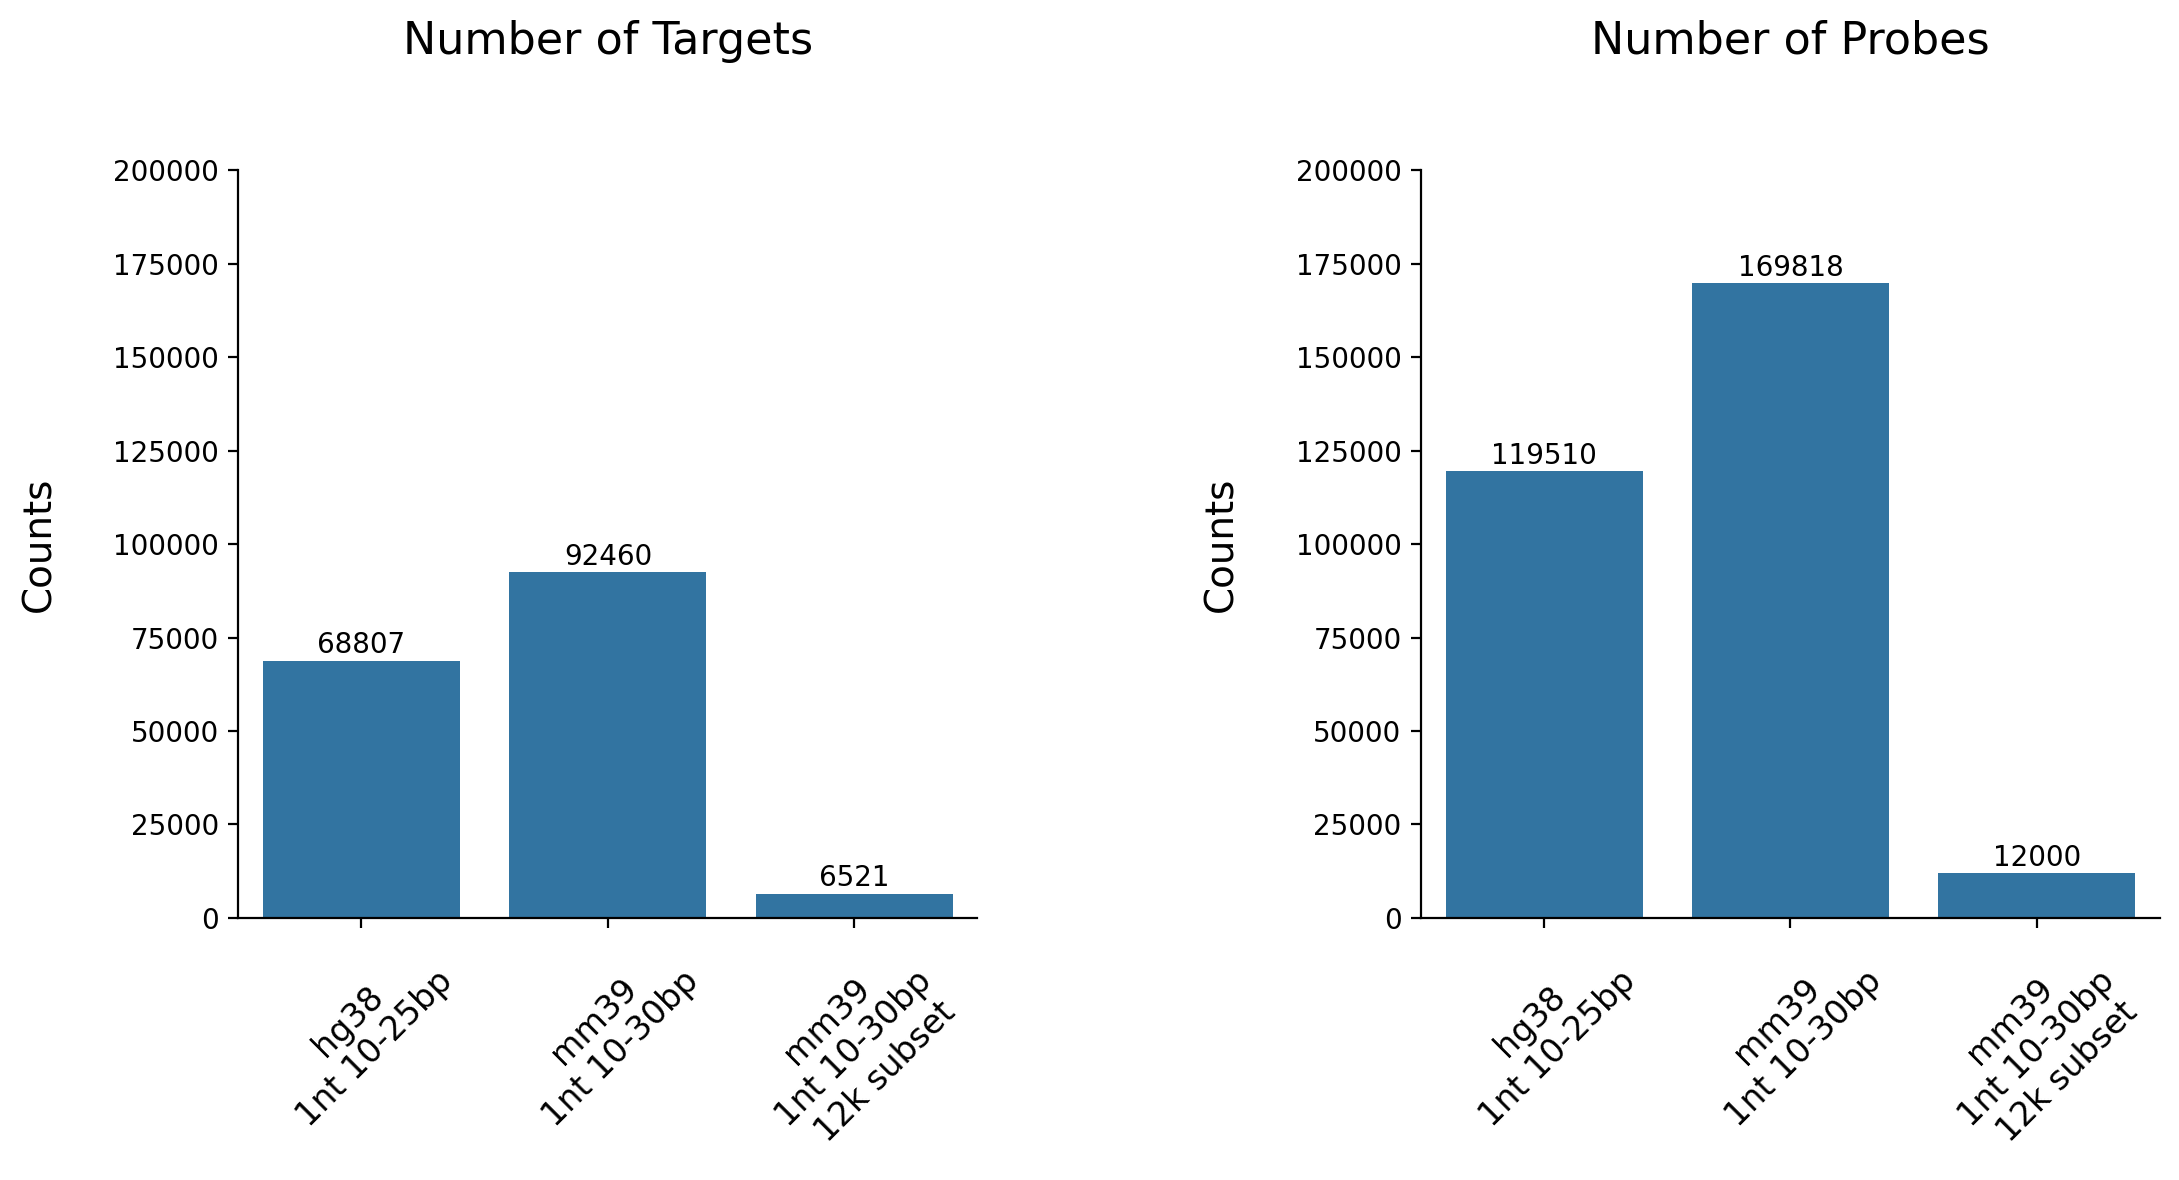

In [37]:
fig, ax = plt.subplots(figsize=(11,6), dpi=200, ncols=2)

# plot n target
sns.barplot(data=count_data, x='name', y='n_target', ax=ax[0])
# plot n probe
sns.barplot(data=count_data, x='name', y='n_probe', ax=ax[1])


ax[0].set_title('Number of Targets\n\n', fontsize=16)
ax[1].set_title('Number of Probes\n\n', fontsize=16)
ax[0].set_ylabel('Counts\n', fontsize=14)
ax[1].set_ylabel('Counts\n', fontsize=14)


for a in ax:
    a.set_xticklabels(a.get_xticklabels(), rotation=45, ha='center', fontsize=12)
    a.set_ylim(0,2e5)
    a.spines['right'].set_visible(False)
    a.spines['top'].set_visible(False)
    a.set_xlabel('')

# add text
for i, n in enumerate(count_data.n_target):
    ax[0].text(i, n+2000, n, ha='center')
for i, n in enumerate(count_data.n_probe):
    ax[1].text(i, n+2000, n, ha='center')

plt.tight_layout()
plt.subplots_adjust(wspace=0.6)
plt.show()

# Plot distribution of Target number of repeats and Target fragment size

In [38]:
# Check distribution of number of repeats in each probe set
num_sub_list = []
for k in TW_probes_full_10to30.keys():
    num_sub_list.append(TW_probes_full_10to30[k]['num_sub'])
    
pd.Series(num_sub_list).value_counts()

10    22063
11    15552
12    11862
13     9187
14     7309
15     5275
16     3734
17     2599
18     2092
19     1663
20     1516
21     1515
22     1484
23     1411
24     1111
25     1002
26      842
27      783
28      654
29      479
30      327
Name: count, dtype: int64

In [39]:
np.median(num_sub_list)

12.0

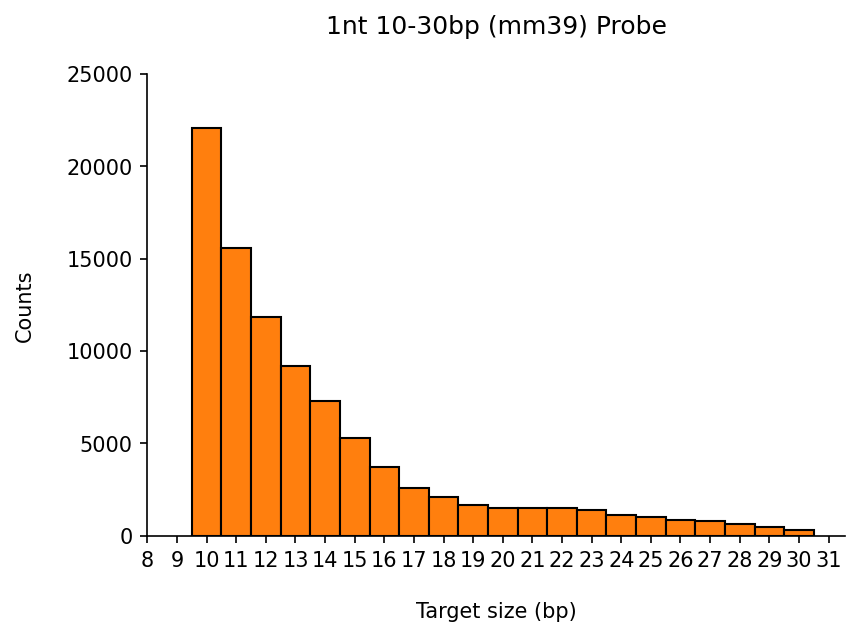

In [ ]:
fig, ax = plt.subplots(figsize=(6,4), dpi=150)

ax.hist(num_sub_list, np.arange(10,32), edgecolor='black', color='tab:orange')

# work around to set n_repeat to center of tick
ax.set_xticks(np.arange(8,32)+0.5)
ax.set_xticklabels(np.arange(8,32))

ax.set_ylim(0,25000)

ax.set_title('1nt 10-30bp (mm39) Probe\n')
ax.set_xlabel('\nTarget size (bp)')
ax.set_ylabel('Counts\n')


ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.show()

In [41]:
# Check distribution of fragment size in each probe set
fragLen_list = []
for k in TW_probes_full_10to30.keys():
    fragLen_list.append(TW_probes_full_10to30[k]['fragLen'])
    
pd.Series(fragLen_list).value_counts()

222    505
225    505
126    496
160    491
127    489
      ... 
484      2
477      2
481      2
482      1
485      1
Name: count, Length: 365, dtype: int64

In [42]:
max(fragLen_list)

485

In [43]:
np.median(fragLen_list)

224.0

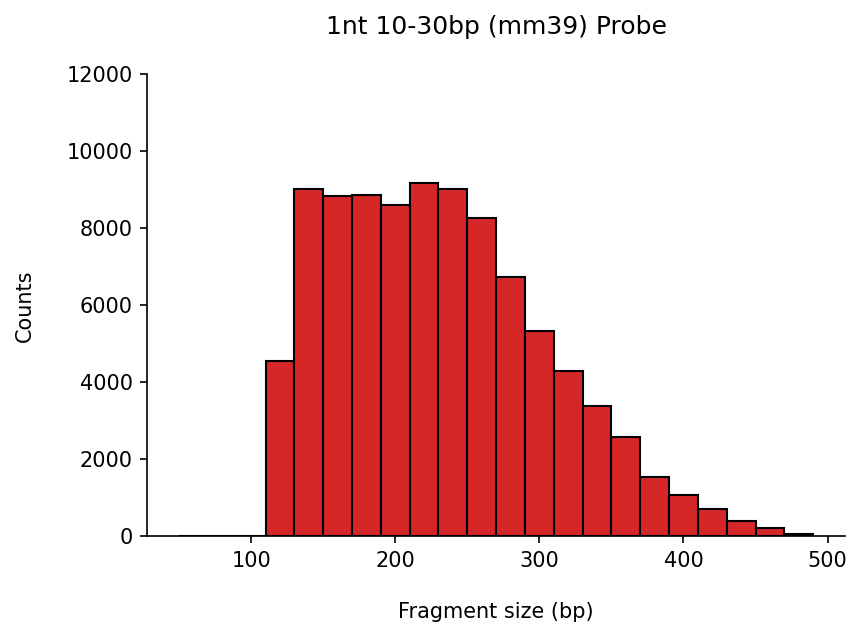

In [44]:
fig, ax = plt.subplots(figsize=(6,4), dpi=150)

ax.hist(fragLen_list, np.arange(50,500,20), edgecolor='black', color='tab:red')

ax.set_ylim(0,12000)

ax.set_title('1nt 10-30bp (mm39) Probe\n')
ax.set_xlabel('\nFragment size (bp)')
ax.set_ylabel('Counts\n')


ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.show()

In [45]:
# check how much dupliates (done in command line)
!sort TW_order_mm39.1nt10-30bp.92460targets169818probes.txt | uniq -c | grep -v '^ *1 ' | awk '{sum += $1} END {print sum}'

223


# For slide plot

In [48]:
count_data = pd.concat([count_data, pd.DataFrame([{'name':'hg38\n1nt 10-25bp', 'n_target': 68807, 'n_probe': 119510}])], ignore_index=True)
count_data = count_data.iloc[[2,0,1],]
count_data

,name,n_target,n_probe
2,mm39\n1nt 10-30bp,92460,169818
0,mm39\n1nt 10-30bp\n 12k subset,6521,12000
1,hg38\n1nt 10-25bp,68807,119510


/tmp/ipykernel_3279715/247505727.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation=45, ha='center', fontsize=12)
/tmp/ipykernel_3279715/247505727.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation=45, ha='center', fontsize=12)


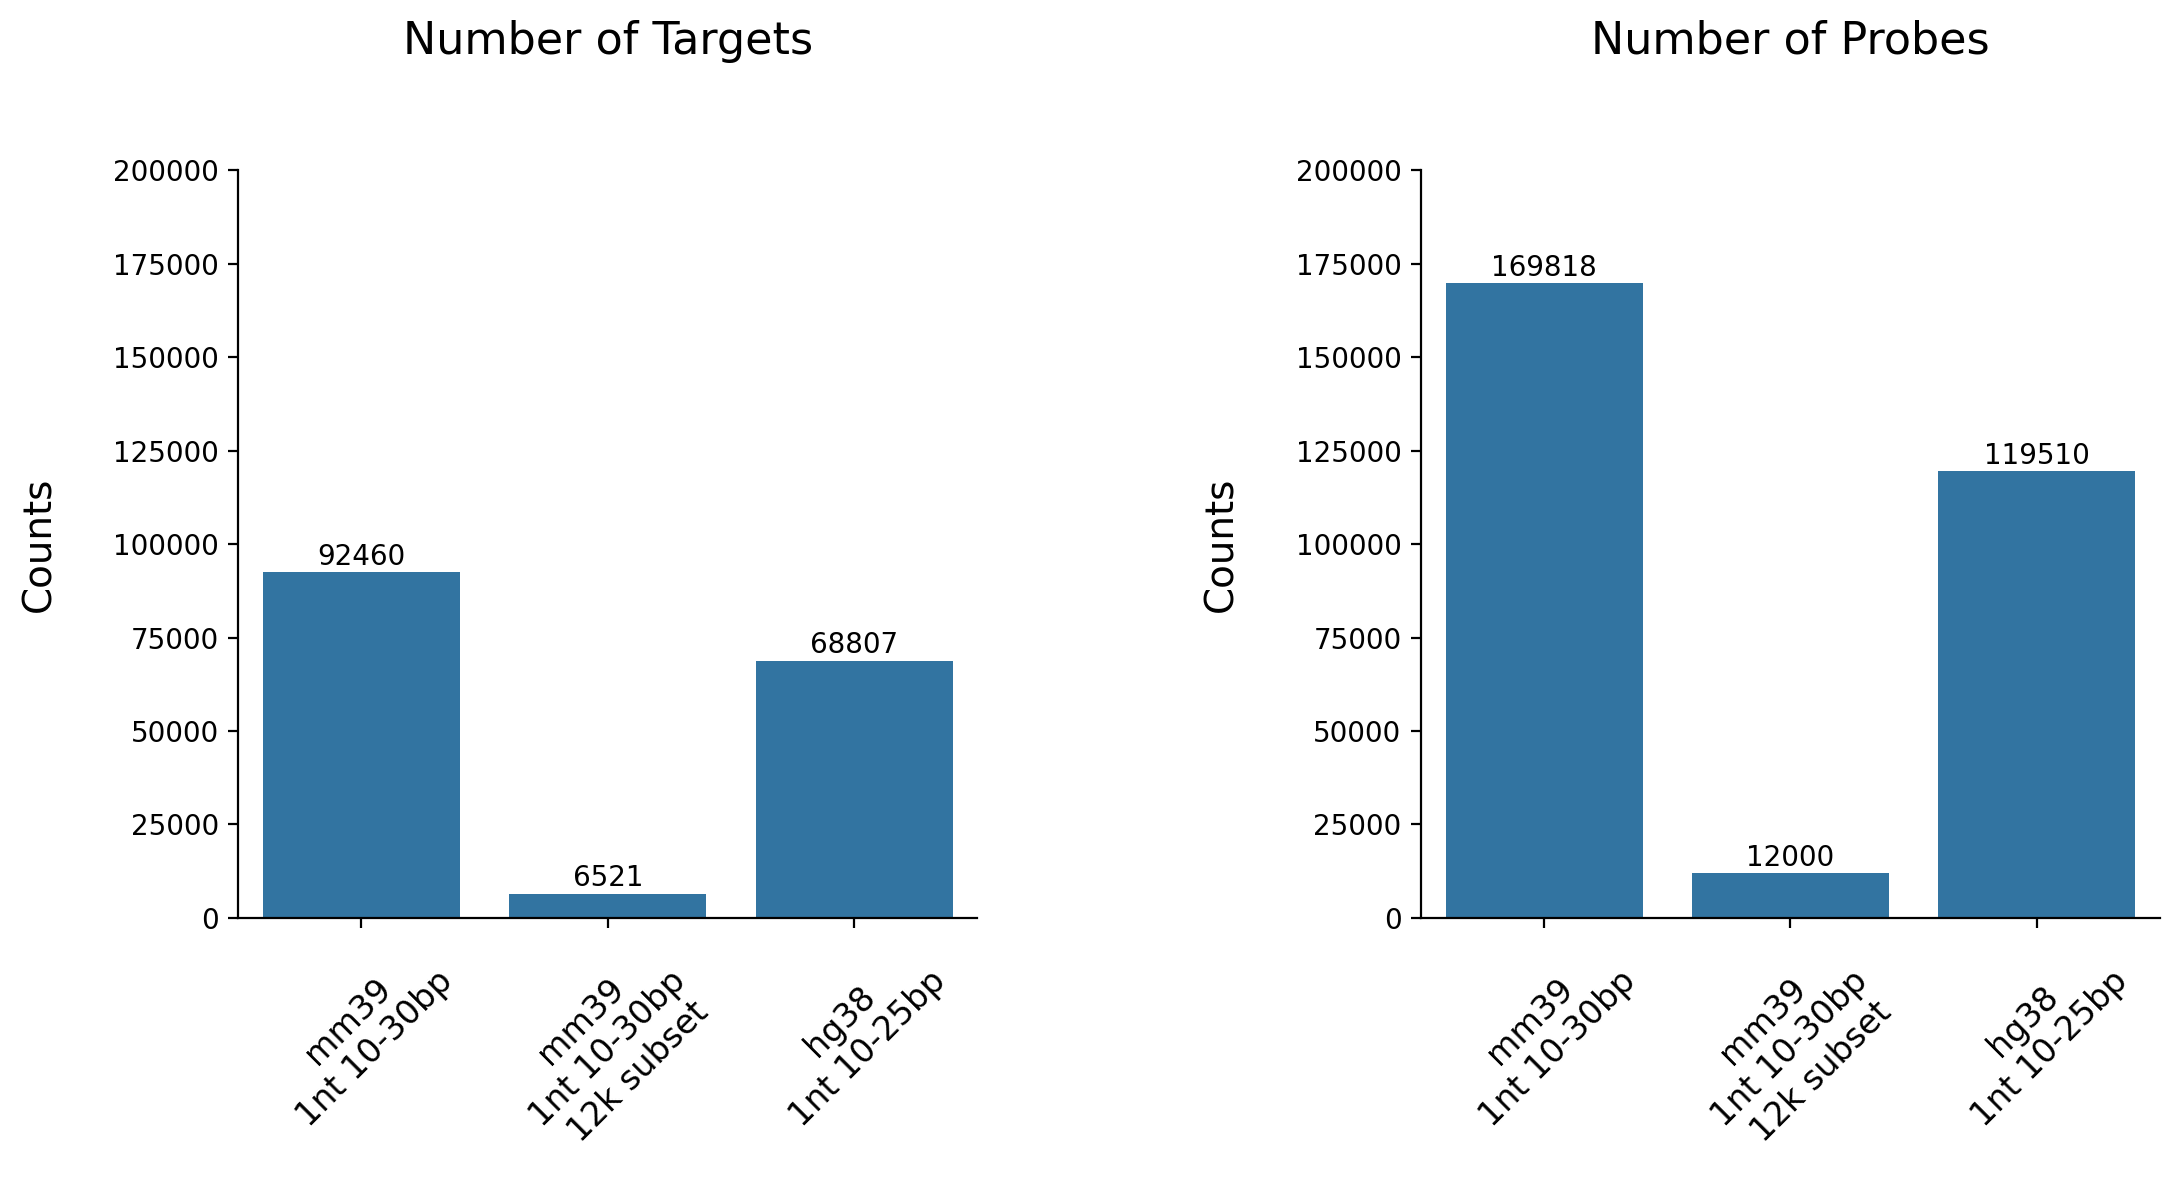

In [49]:
fig, ax = plt.subplots(figsize=(11,6), dpi=200, ncols=2)

# plot n target
sns.barplot(data=count_data, x='name', y='n_target', ax=ax[0])
# plot n probe
sns.barplot(data=count_data, x='name', y='n_probe', ax=ax[1])


ax[0].set_title('Number of Targets\n\n', fontsize=16)
ax[1].set_title('Number of Probes\n\n', fontsize=16)
ax[0].set_ylabel('Counts\n', fontsize=14)
ax[1].set_ylabel('Counts\n', fontsize=14)


for a in ax:
    a.set_xticklabels(a.get_xticklabels(), rotation=45, ha='center', fontsize=12)
    a.set_ylim(0,2e5)
    a.spines['right'].set_visible(False)
    a.spines['top'].set_visible(False)
    a.set_xlabel('')

# add text
for i, n in enumerate(count_data.n_target):
    ax[0].text(i, n+2000, n, ha='center')
for i, n in enumerate(count_data.n_probe):
    ax[1].text(i, n+2000, n, ha='center')

plt.tight_layout()
plt.subplots_adjust(wspace=0.6)
plt.show()

# For publication

In [64]:
count_data_filtered = count_data.iloc[[2,0],]
count_data_filtered

,name,n_target,n_probe
1,hg38\n1nt 10-25bp,68807,119510
2,mm39\n1nt 10-30bp,92460,169818


In [65]:
count_data_filtered['rename'] = ['RETrace v2\nhg38', 'RETrace v2\nmm39']
count_data_filtered

/tmp/ipykernel_3279715/262430059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  count_data_filtered['rename'] = ['RETrace v2\nhg38', 'RETrace v2\nmm39']


,name,n_target,n_probe,rename
1,hg38\n1nt 10-25bp,68807,119510,RETrace v2\nhg38
2,mm39\n1nt 10-30bp,92460,169818,RETrace v2\nmm39


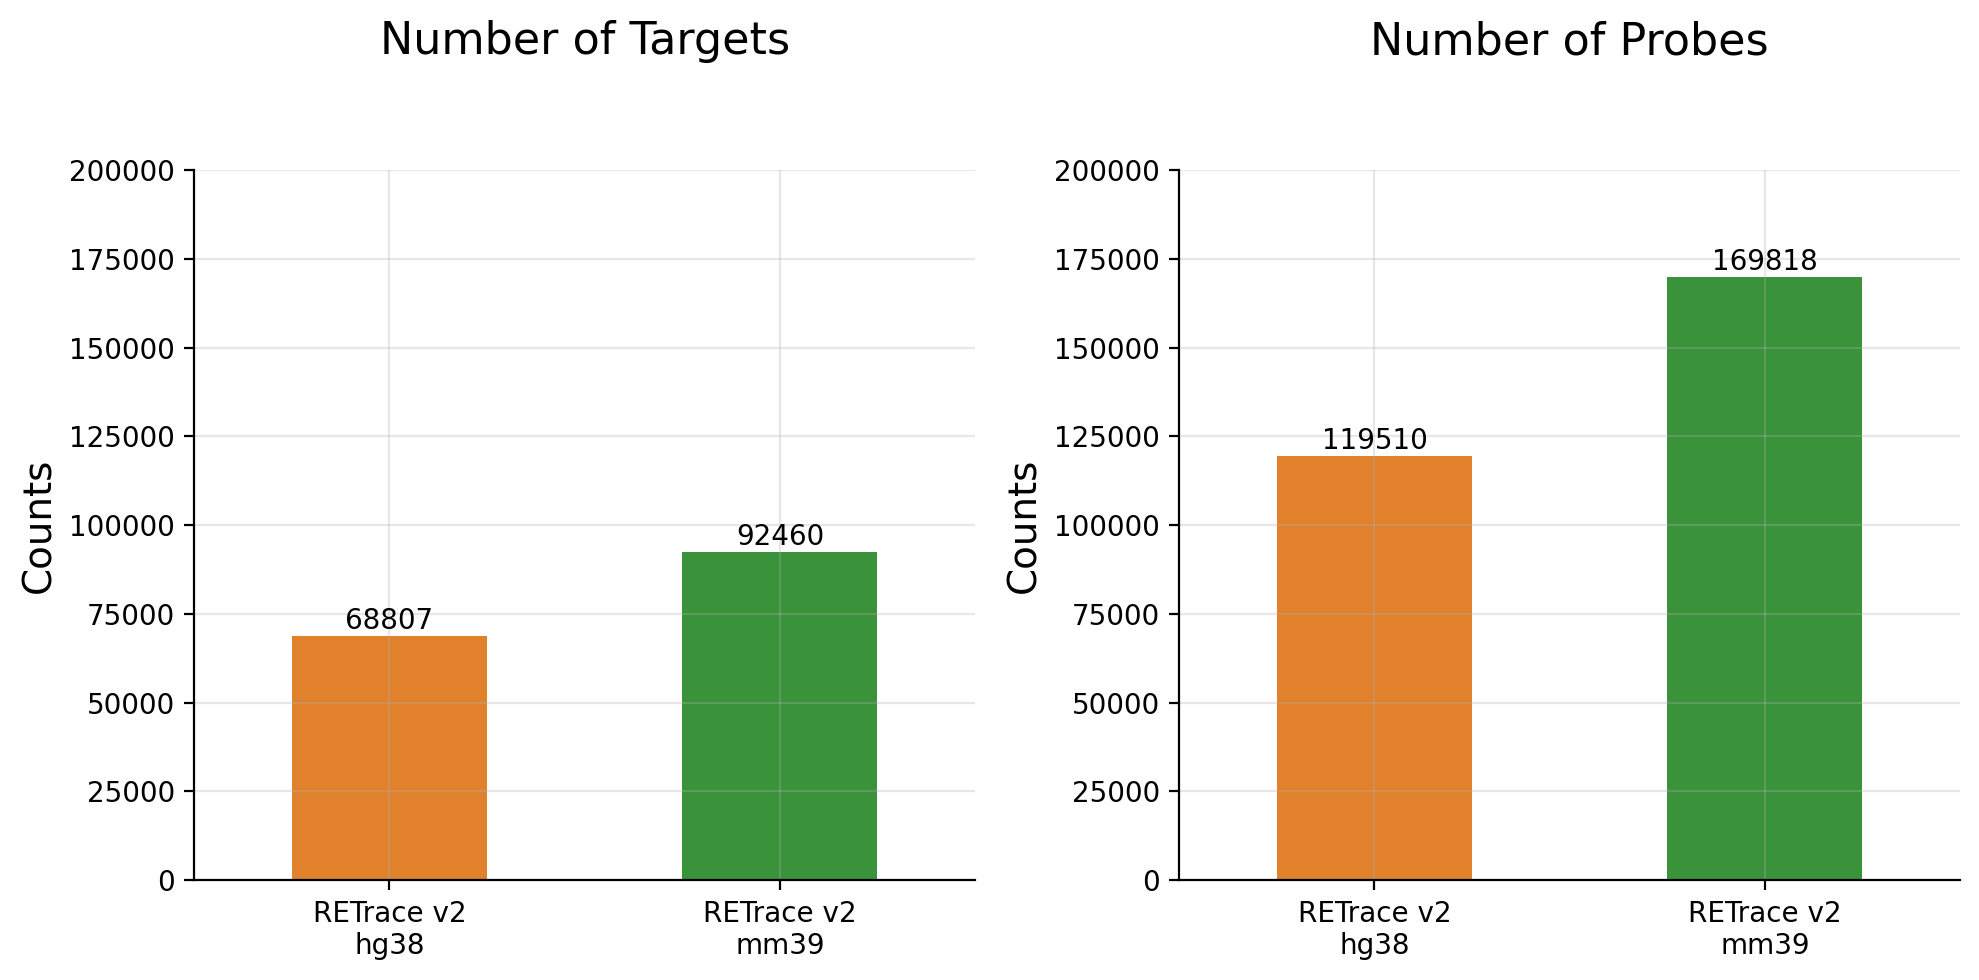

In [70]:
fig, ax = plt.subplots(figsize=(10,5), dpi=200, ncols=2)

# plot n target
sns.barplot(data=count_data_filtered, x='rename', y='n_target', ax=ax[0], hue='rename', palette=['tab:orange', 'tab:green'], width=0.5)
# plot n probe
sns.barplot(data=count_data_filtered, x='rename', y='n_probe', ax=ax[1], hue='rename', palette=['tab:orange', 'tab:green'], width=0.5)

ax[0].set_title('Number of Targets\n\n', fontsize=16)
ax[1].set_title('Number of Probes\n\n', fontsize=16)
ax[0].set_ylabel('Counts', fontsize=14)
ax[1].set_ylabel('Counts', fontsize=14)

for a in ax:
    a.set_ylim(0,2e5)
    a.spines['right'].set_visible(False)
    a.spines['top'].set_visible(False)
    a.set_xlabel('')
    a.grid(True, alpha=0.3)

#ax[0].set_ylim(0,1e5)

# add text
for i, n in enumerate(count_data_filtered.n_target):
    ax[0].text(i, n+2000, n, ha='center')
for i, n in enumerate(count_data_filtered.n_probe):
    ax[1].text(i, n+2000, n, ha='center')

plt.tight_layout()
plt.savefig('RETrace_v2_probe_hg38_mm39_comparison.pdf')
plt.show()

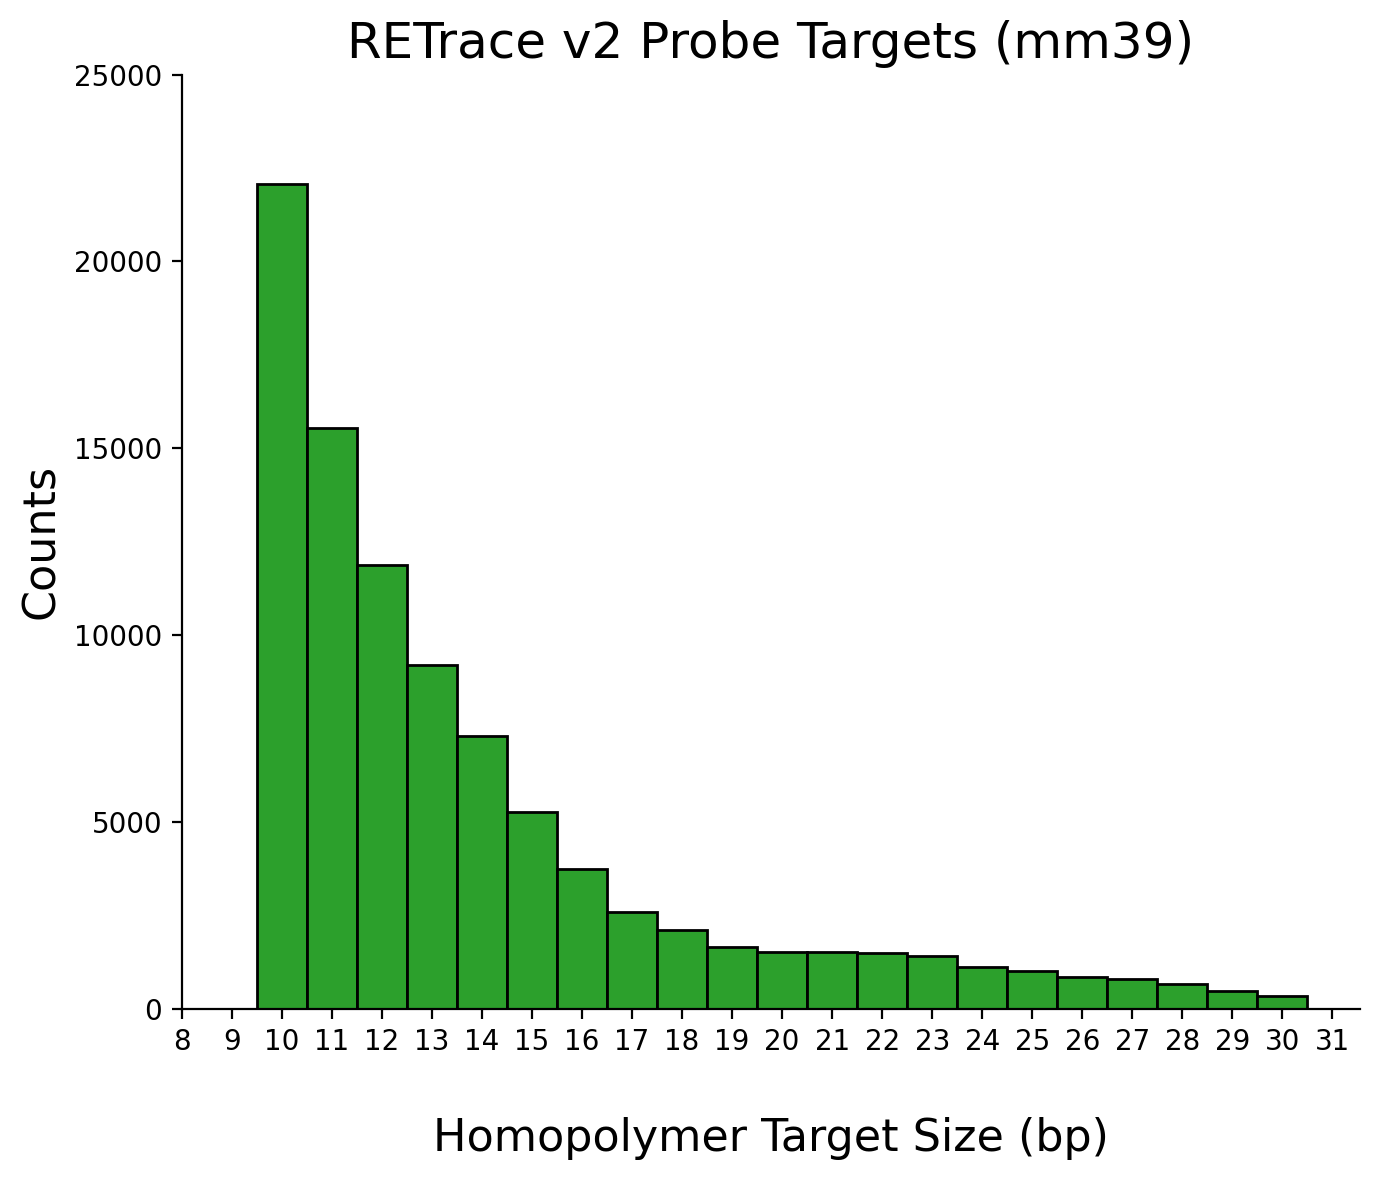

In [91]:
fig, ax = plt.subplots(figsize=(7,6), dpi=200)

ax.hist(num_sub_list, np.arange(10,32), edgecolor='black', color='tab:green')

# work around to set n_repeat to center of tick
ax.set_xticks(np.arange(8,32)+0.5)
ax.set_xticklabels(np.arange(8,32))

ax.set_ylim(0,25000)

ax.set_title('RETrace v2 Probe Targets (mm39)', fontsize=18)
ax.set_xlabel('\nHomopolymer Target Size (bp)', fontsize=16)
ax.set_ylabel('Counts', fontsize=16)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('RETrace_v2_probe_mm39_target_size_distribution.pdf')
plt.show()

In [ ]:
# fig, ax = plt.subplots(figsize=(6,4), dpi=150)

# ax.hist(fragLen_list, np.arange(50,500,20), edgecolor='black', color='tab:red')

# ax.set_ylim(0,12000)

# ax.set_title('1nt 10-30bp (mm39) Probe\n')
# ax.set_xlabel('\nFragment size (bp)')
# ax.set_ylabel('Counts\n')


# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)

# plt.show()